In [1]:
import rasterio
import os
import re
import matplotlib.pyplot as plt
import numpy as np
from rasterio.transform import TransformMethodsMixin
from rasterio.warp import calculate_default_transform, reproject, Resampling
import earthaccess
import sys
from scipy.ndimage import binary_dilation
from pyproj import Transformer
import random
from collections import Counter
from cupyx.scipy.ndimage import convolve
import cupy as cp
import leafmap
from samgeo import SamGeo, tms_to_geotiff, get_basemaps
import tools as ts

In [2]:
segmented_path = "/mnt/c/Users/attic/planet_mask/segmented_20201108_184604_80_2206_3B_AnalyticMS_SR_8b_harmonized_clip.tif"
file = '20201108_184604_80_2206_3B_AnalyticMS_SR_8b_harmonized_clip.tif'
img_path ='/mnt/c/Users/attic/planet_mask/PlanetScope_VarietyCoaslines'
file_path = os.path.join(img_path,file)

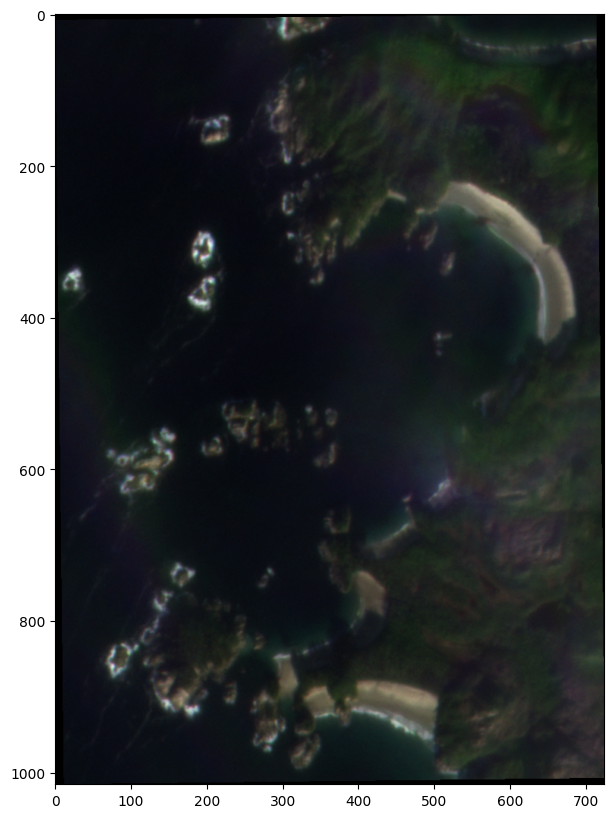

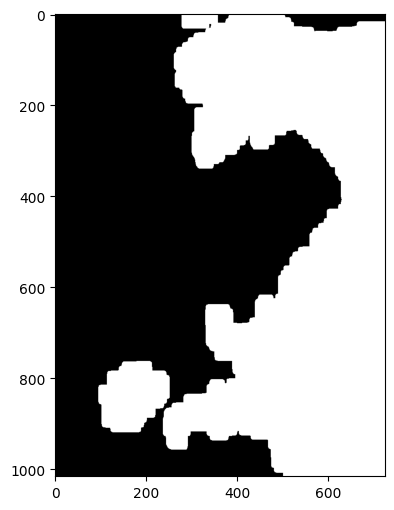

(1016, 725, 3)
Running MESMA
106
(1, 1016, 725)


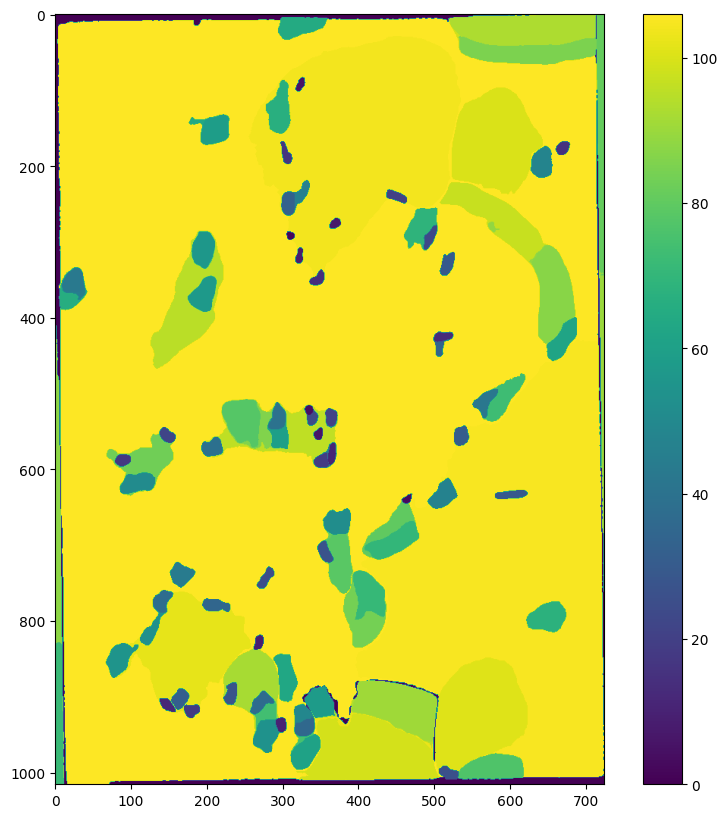

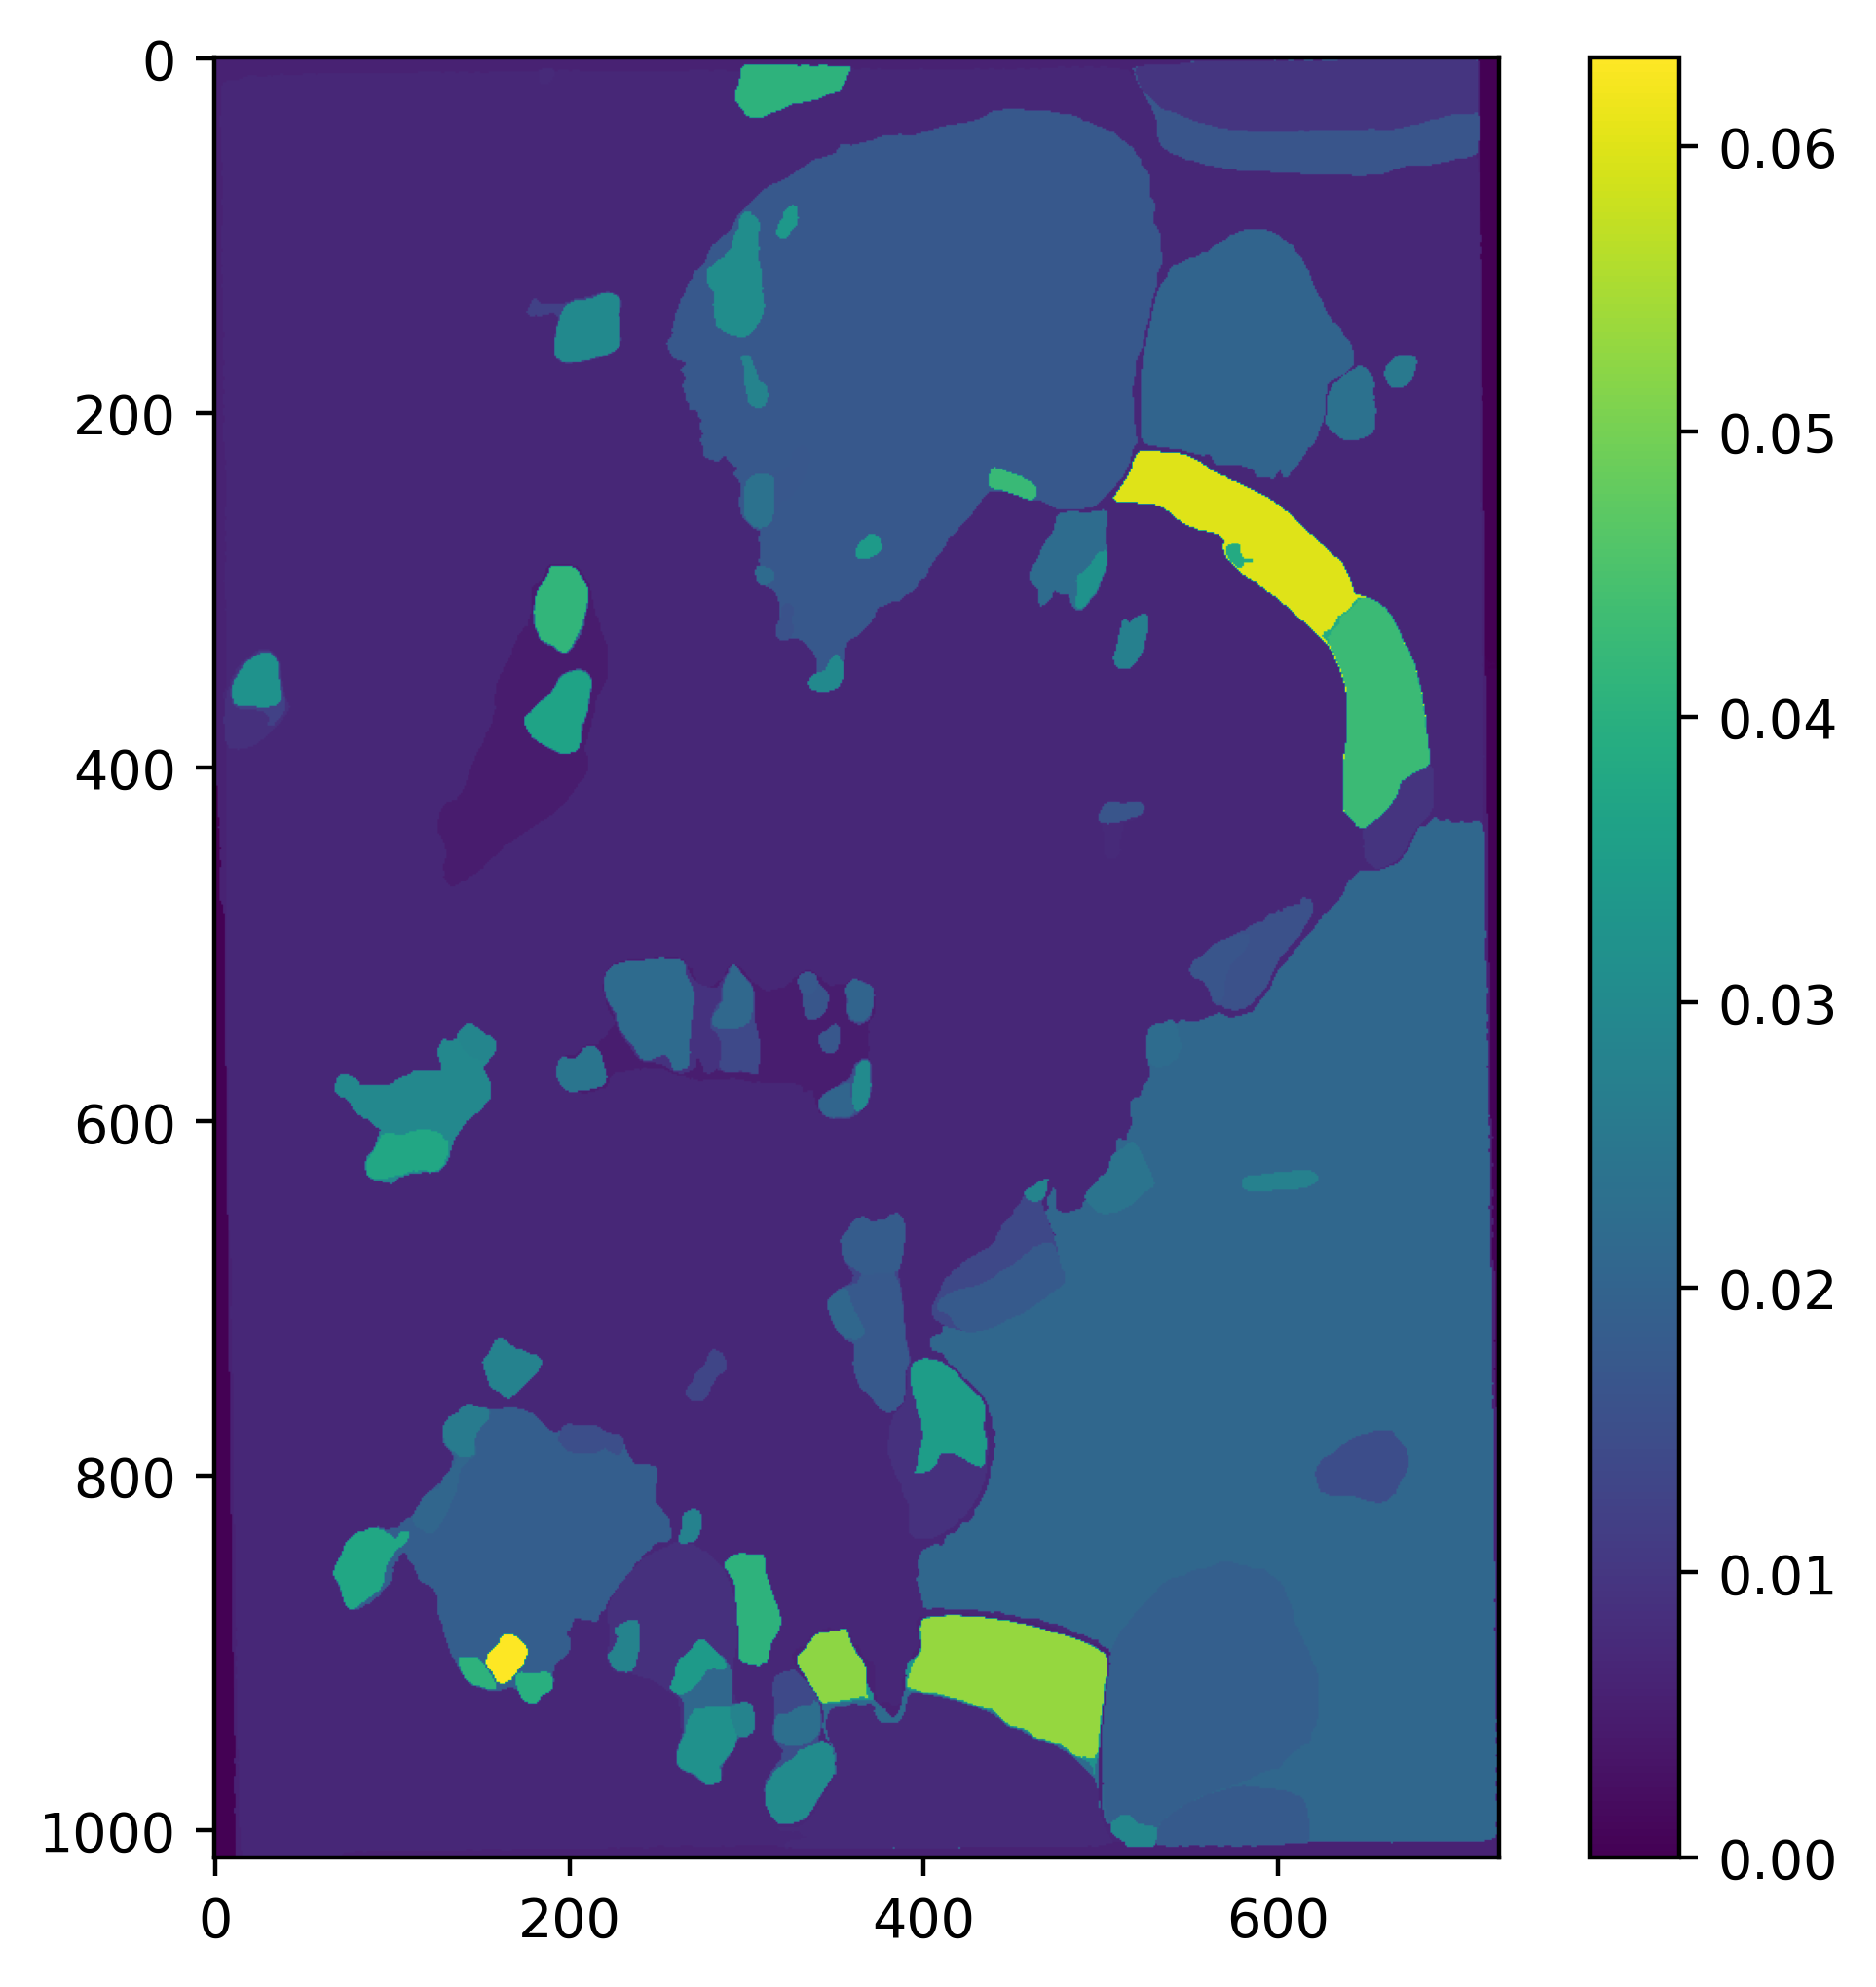

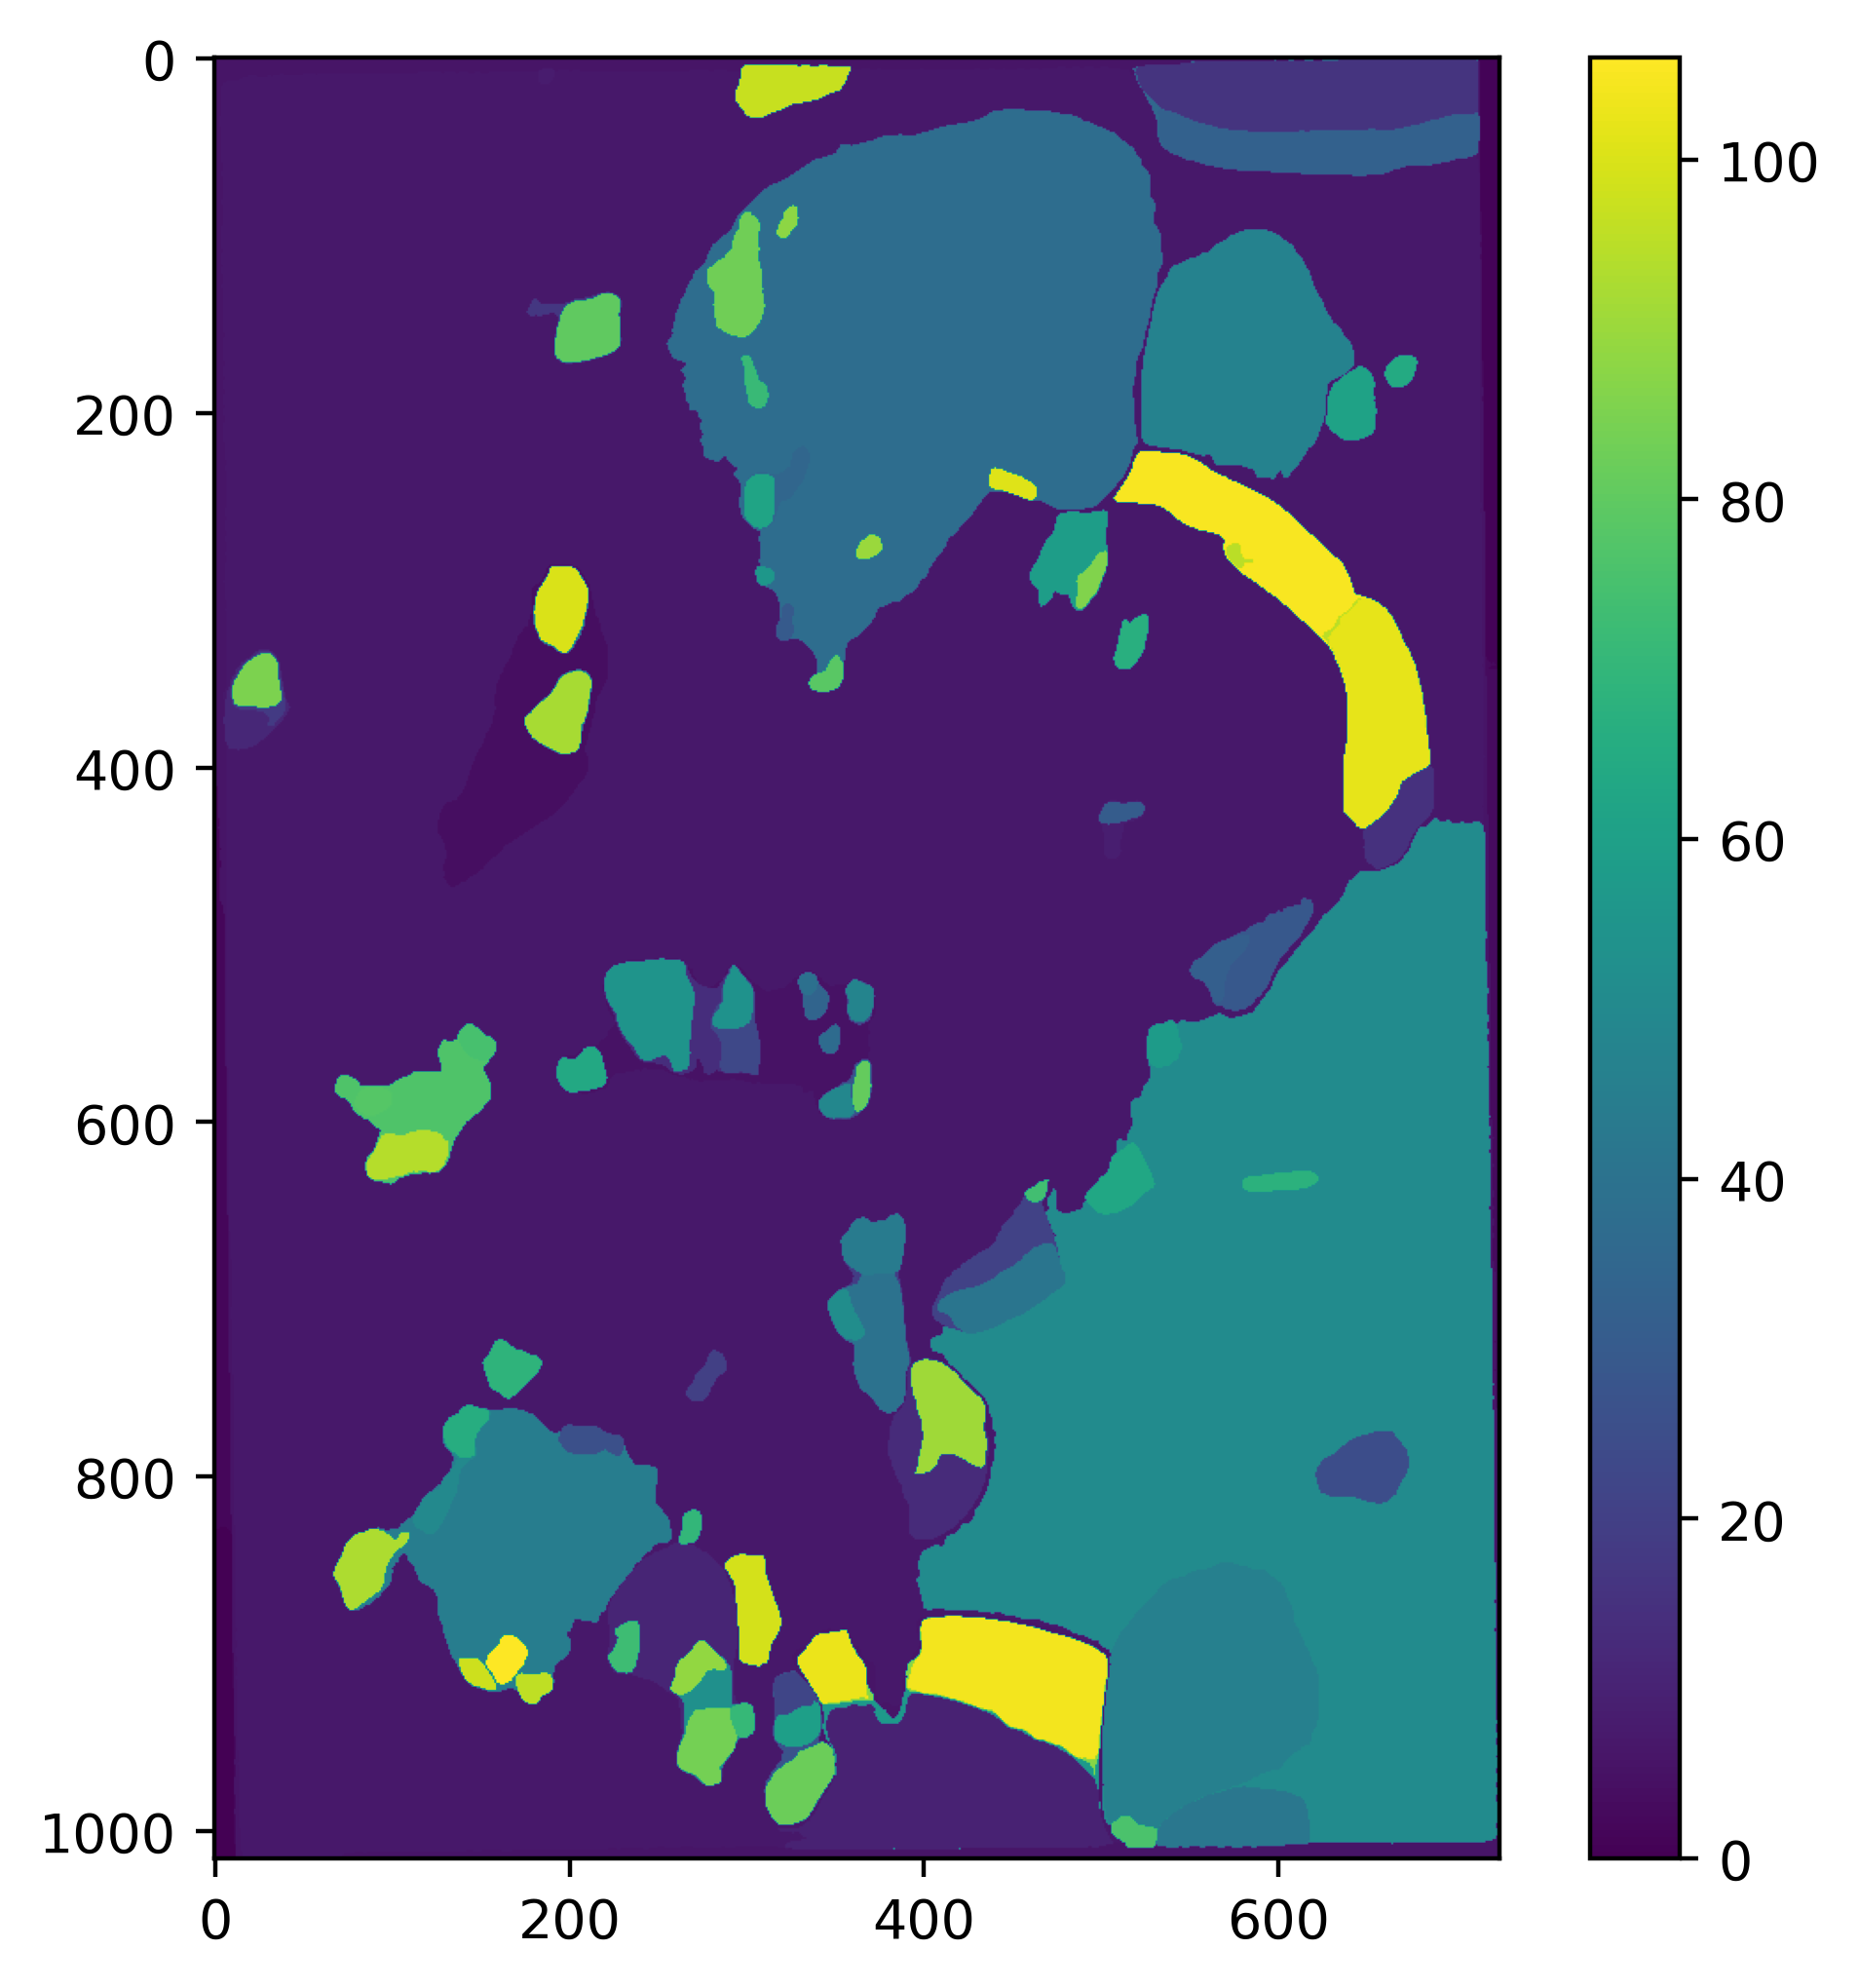

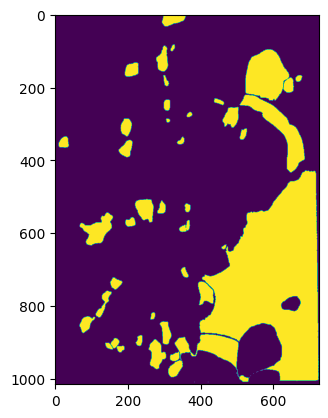

In [21]:
with rasterio.open(file_path, 'r') as src:
    bands = src.read()
    crs = src.crs
    transform = src.transform
file
ts.view_rgb(bands)

dem_path = os.path.join(r'/mnt/c/Users/attic/planet_mask/dem',file.rstrip(".tif")) 
if not os.path.isdir(dem_path):
    os.mkdir(dem_path)
    ts.download_dem(file_path,dem_path)
land_mask = ts.create_land_mask(file_path,dem_path=dem_path, show_image=True, land_dilation=25) #Create highly diluted DEM-based landmask, to get you the pure ocean for endmember selection 
ocean = np.where(land_mask, 0, bands)
endmembers = ts.select_ocean_endmembers(ocean)

packet = ts.unmix_ocean(bands,ocean_EM=endmembers) #Spectral unmixing 
ocean, minvals = packet
minvals_ocean = np.where(land_mask,np.nan, minvals)

with rasterio.open(segmented_path,'r') as src:
    mask = src.read()
bands = np.max(mask[0])
print(bands)
print(mask.shape)
plt.figure(figsize=(10,10))
plt.imshow(mask[0])
plt.colorbar()
plt.show()
mask = mask[0]
new_mask = np.zeros_like(mask)
incremental_mask = np.zeros_like(mask)
for i in range(bands+1):
    segment = np.where(mask == i, minvals,np.nan)
    mean_value = np.nanmean(segment)
    new_mask = np.where(mask == i, mean_value, new_mask)

unique_vals = np.sort(np.unique(new_mask))
for i, val in enumerate(unique_vals):
    incremental_mask = np.where(new_mask == val, i, incremental_mask)
plt.figure(figsize=(6,6), dpi=400 )
plt.imshow(new_mask)
plt.colorbar()
plt.show()
plt.figure(figsize=(6,6), dpi=400 )
plt.imshow(incremental_mask)
plt.colorbar()
plt.show()

land_mask = new_mask > .02
plt.figure()
plt.imshow(land_mask)
plt.show()